In [96]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
import os

In [ ]:
load_dotenv()
os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [98]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [ ]:
searchTool = DuckDuckGoSearchRun(region ="us-en")

# Custom Calculator tool
@tool
def calculator(a: float, b: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operations on two numbers a and b,
    Supported operations: add, sub, mul, div.
    """
    try:
        if operation == "add":
            result = a+b
        elif operation == "sub":
            result = a-b
        elif operation == "mul":
            result = a*b
        elif operation == "div":
            if(b == 0): return {"error": "Division by zero is not allowed"}
            result = a/b
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        return {"Result: ", result}
    except Exception as e:
        return {"error": str(e)}

@tool
def getStockPrice(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g 'AAPL', 'TSLA')
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey="
    response = requests.get(url)
    return response.json()

WHETHER_API_KEY = ""
@tool
def getWhetherDetials(city: str) -> dict:
    """
    Get the current weather for a city.
    Args:
        city: Name of the city (e.g., Delhi, Mumbai, London)
    """
    url = (
        f"https://api.openweathermap.org/data/2.5/weather"
        f"?q={city}"
        f"&units=metric"
        f"&appid={WHETHER_API_KEY}"
    )

    response = requests.get(url)

    if response.status_code != 200:
        return {"error": "City not found"}

    data = response.json()

    return {
        "city": data["name"],
        "country": data["sys"]["country"],
        "temperature": data["main"]["temp"],
        "feels_like": data["main"]["feels_like"],
        "humidity": data["main"]["humidity"],
        "weather": data["weather"][0]["main"],
        "description": data["weather"][0]["description"],
        "wind_speed": data["wind"]["speed"],
    }

CONVERSION_API_KEY = ""
@tool
def currencyConverter(amount: float,from_currency: str, to_currency: str) -> dict:
    """
    Convert an amount from one currency to another.

    Args:
        amount: Amount to convert.
        from_currency: Source currency code (USD, INR, EUR...)
        to_currency: Target currency code (INR, USD, GBP...)
    """

    url = (
        "https://api.exchangerate.host/convert"
        f"?access_key={CONVERSION_API_KEY}"
        f"&from={from_currency.upper()}"
        f"&to={to_currency.upper()}"
        f"&amount={amount}"
    )

    try:
        response = requests.get(url, timeout=10)
        data = response.json()

        # Debug (remove later)
        print("Status Code:", response.status_code)
        print("Response:", data)

        if response.status_code != 200:
            return {
                "error": f"HTTP Error {response.status_code}"
            }

        if not data.get("success", False):
            return {
                "error": data
            }

        return {
            "amount": amount,
            "from": from_currency.upper(),
            "to": to_currency.upper(),
            "converted_amount": data["result"],
            "exchange_rate": data["info"]["quote"]   # <-- FIXED
        }

    except Exception as e:
        return {
            "error": str(e)
        }

In [113]:
tools = [searchTool, calculator, getStockPrice, getWhetherDetials, currencyConverter]
llmTools = model.bind_tools(tools)

In [114]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [115]:
def chatNode(state: ChatState):
    "LLM node that may chat with the user or request a tool call"
    messages = state['messages']
    response = llmTools.invoke(messages)
    return {"messages": [response]}

toolNode = ToolNode(tools)

In [116]:
graph = StateGraph(ChatState)

graph.add_node("chatNode", chatNode)
graph.add_node("tools", toolNode)

graph.add_edge(START, "chatNode")

graph.add_conditional_edges("chatNode",tools_condition)

graph.add_edge("tools", "chatNode")

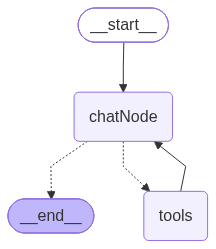

In [117]:
chatBot = graph.compile()
chatBot

In [105]:
response = chatBot.invoke({"messages": HumanMessage(content = "Hello!")})
print(response['messages'][-1].content)

Hello! How can I assist you today? 😊


In [ ]:
response = chatBot.invoke({"messages": HumanMessage(content = "Use the calculator tool to multiply 123 and 456.")})
for msg in response["messages"]:
    print("=" * 50)
    print(type(msg).__name__)
    print(msg)

In [ ]:
response = chatBot.invoke({"messages": HumanMessage(content = "What is the current weather in Delhi?")})
for msg in response["messages"]:
    print("=" * 50)
    print(type(msg).__name__)
    print(msg)

In [ ]:
response = chatBot.invoke({"messages": HumanMessage(content = "What's the current price of TSLA stock?")})
for msg in response["messages"]:
    print("=" * 50)
    print(type(msg).__name__)
    print(msg)

In [ ]:
response = chatBot.invoke({"messages": HumanMessage(content = "Convert 100 USD to INR.")})
for msg in response["messages"]:
    print("=" * 50)
    print(type(msg).__name__)
    print(msg)